In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('MSCAD.csv')

In [3]:
df

,'Flow Duration','Tot Fwd Pkts','Tot Bwd Pkts','TotLen Fwd Pkts','TotLen Bwd Pkts','Fwd Pkt Len Max','Fwd Pkt Len Min','Fwd Pkt Len Mean','Fwd Pkt Len Std','Bwd Pkt Len Max',...,'Fwd Act Data Pkts','Active Mean','Active Std','Active Max','Active Min','Idle Mean','Idle Std','Idle Max','Idle Min',Label
0,1518,2,5,110,377,110,0,55.0000,77.7817,377,...,1,0,0,0,0,0,0,0,0,Brute_Force
1,5894,4,8,168,4498,168,0,42.0000,84.0000,1460,...,1,0,0,0,0,0,0,0,0,Brute_Force
2,272,1,1,0,0,0,0,0.0000,0.0000,0,...,0,0,0,0,0,0,0,0,0,Brute_Force
3,2611,4,8,322,4434,322,0,80.5000,161.0000,1460,...,1,0,0,0,0,0,0,0,0,Brute_Force
4,294,1,1,0,0,0,0,0.0000,0.0000,0,...,0,0,0,0,0,0,0,0,0,Brute_Force
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128794,68942,3,2,517,0,517,0,172.3333,298.4901,0,...,1,0,0,0,0,0,0,0,0,Normal
128795,63327,2,2,1277,1356,1277,0,638.5000,902.9754,1356,...,1,0,0,0,0,0,0,0,0,Normal
128796,139061,3,3,517,0,517,0,172.3333,298.4901,0,...,1,0,0,0,0,0,0,0,0,Normal
128797,21641848,2,5,0,1,0,0,0.0000,0.0000,1,...,0,3242118,0,3242118,3242118,10100000,0,10100000,10100000,Normal


In [4]:
df['Label'].value_counts()

Label
Brute_Force    88502
Normal         28502
Port_Scan      11081
HTTP_DDoS        641
ICMP_Flood        45
Web_Crwling       28
Name: count, dtype: int64

In [5]:
# Paste ini setelah kamu sudah memiliki `df` (pandas DataFrame)
# Contoh: df = pd.read_csv("MSCAD.csv"); lalu paste & panggil fungsi di bawah.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

def visualize_mscad_from_df(
    df,
    ts_col=None,       # override timestamp column name (string) or None to autodetect
    src_col=None,      # override source/attacker column name
    dst_col=None,      # override destination/target column name
    label_col=None,    # override label/attack-type column name
    filter_attacker=None,  # e.g. "192.168.1.30" or None
    show_plot=True,
    return_clean_df=True
):
    """
    Visualize MSCAD-like dataframe events over time per target, coloring by inferred attack type and mapping to CKC stage.
    Returns cleaned DataFrame (if return_clean_df=True) with columns:
      ['ts','src','dst','raw_label','simple_type','ckc_stage','dst_cat']
    """
    # --- helper utilities ---
    def find_col(df, candidates):
        cols = [c.lower() for c in df.columns]
        for name in candidates:
            if name and name.lower() in cols:
                return df.columns[cols.index(name.lower())]
        for name in candidates:
            if not name: continue
            for i,c in enumerate(cols):
                if name.lower() in c:
                    return df.columns[i]
        return None

    def parse_timestamp_series(s):
        if pd.api.types.is_numeric_dtype(s):
            return s.astype(float)
        parsed = pd.to_datetime(s, errors='coerce', infer_datetime_format=True)
        if parsed.notna().sum() > 0:
            return parsed.astype('int64') // 10**9
        def try_dt(x):
            for fmt in ("%Y-%m-%d %H:%M:%S","%Y/%m/%d %H:%M:%S",
                        "%d/%m/%Y %H:%M:%S","%m/%d/%Y %H:%M:%S"):
                try:
                    return int(datetime.strptime(str(x), fmt).timestamp())
                except:
                    pass
            return np.nan
        return s.apply(try_dt)

    # --- autodetect columns if overrides not provided ---
    ts_col = ts_col or find_col(df, ["timestamp","time","date","datetime","ts"])
    src_col = src_col or find_col(df, ["src","source","attacker","ip_src","src_ip","address"])
    dst_col = dst_col or find_col(df, ["dst","dest","destination","target","dst_ip","ip_dst"])
    label_col = label_col or find_col(df, ["label","attack","type","event","activity","category","classification","proto","label"])

    # Build core DF
    core = pd.DataFrame()
    core['ts'] = parse_timestamp_series(df[ts_col]) if ts_col is not None else np.arange(len(df))
    core['src'] = df[src_col].astype(str) if src_col is not None else df.index.astype(str)
    core['dst'] = df[dst_col].astype(str) if dst_col is not None else "unknown_target"
    core['raw_label'] = df[label_col].astype(str).fillna("unknown") if label_col is not None else "unknown"

    # optional filter by attacker IP
    if filter_attacker:
        core = core[core['src'] == filter_attacker]

    # mapping heuristics (edit/add keywords as needed)
    TYPE_MAP = {
        'port': 'PortScan',
        'scan': 'PortScan',
        'brute': 'BruteForce',
        'httrack': 'Crawler',
        'crawler': 'Crawler',
        'http': 'HTTP',
        'slowloris': 'Slowloris',
        'ddos': 'DDoS',
        'radware': 'DDoS',
        'syn': 'PortScan',
        'fin': 'PortScan',
        'udp': 'PortScan',
        'ftp': 'FTP',
        'ssh': 'SSH',
        'login': 'BruteForce',
        'auth': 'BruteForce',
        'malware': 'Malware',
        'bot': 'Botnet',
        'dos': 'DDoS',
    }
    CKC_MAP = {
        'PortScan': 'Reconnaissance',
        'Crawler': 'Reconnaissance',
        'BruteForce': 'Credential Access',
        'Slowloris': 'Exploitation/DoS',
        'DDoS': 'Impact',
        'HTTP': 'Reconnaissance/Exploitation',
        'SSH': 'Lateral Movement',
        'FTP': 'Lateral Movement',
        'Malware': 'Delivery/Execution',
        'Botnet': 'C2',
        'Unknown': 'Unknown',
    }

    def map_to_simple(label):
        s = str(label).lower()
        for k,v in TYPE_MAP.items():
            if k in s:
                return v
        token = str(label).split()[0]
        token = token[:20].replace(" ","_")
        return token if token else "Unknown"

    core['simple_type'] = core['raw_label'].apply(map_to_simple)
    core['ckc_stage'] = core['simple_type'].map(CKC_MAP).fillna('Other')

    # drop NaN timestamps and sort
    core = core.dropna(subset=['ts']).sort_values('ts').reset_index(drop=True)

    # order targets by frequency (most frequent on bottom)
    target_order = core['dst'].value_counts().index.tolist()[::-1]
    core['dst_cat'] = pd.Categorical(core['dst'], categories=target_order, ordered=True)

    # prepare visuals
    unique_types = sorted(core['simple_type'].unique())
    markers = ['o','s','X','+','D','^','v','<','>','p','h','*']
    marker_map = {t: markers[i % len(markers)] for i,t in enumerate(unique_types)}
    ckc_levels = sorted(core['ckc_stage'].unique())
    cmap = plt.get_cmap('tab10')
    ckc_color_map = {st: cmap(i % 10) for i,st in enumerate(ckc_levels)}

    if show_plot:
        plt.figure(figsize=(14,9))
        ax = plt.gca()
        for t in unique_types:
            sub = core[core['simple_type'] == t]
            if sub.empty: continue
            y = sub['dst_cat'].cat.codes
            ax.scatter(sub['ts'], y, label=f"{t} ({sub['ckc_stage'].iloc[0]})",
                       marker=marker_map[t], s=40, alpha=0.9,
                       c=[ckc_color_map[sub['ckc_stage'].iloc[0]]])
        ax.set_yticks(range(len(target_order)))
        ax.set_yticklabels(target_order, fontsize=8)
        ax.set_ylabel("Target (destination IP / identifier)")
        ax.set_xlabel("Timestamp (epoch seconds or numeric field)")
        ax.set_title("MSCAD-like: Events over time per target, colored by inferred attack type / CKC stage")
        ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), fontsize=8)
        plt.tight_layout()
        plt.show()

    if return_clean_df:
        return core
    else:
        return None

# ---------------- Example usage ----------------
# cleaned = visualize_mscad_from_df(df)                      # autodetect columns
# cleaned = visualize_mscad_from_df(df, ts_col="Timestamp")  # if you want to override
# cleaned = visualize_mscad_from_df(df, filter_attacker="192.168.1.30") # filter one attacker


In [6]:
df2 = pd.read_csv('Network_dataset_1.csv')

C:\Users\62811\AppData\Local\Temp\ipykernel_34920\3227792504.py:1: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  df2 = pd.read_csv('Network_dataset_1.csv')


In [7]:
df2

,ts,src_ip,src_port,dst_ip,dst_port,proto,service,duration,src_bytes,dst_bytes,...,http_response_body_len,http_status_code,http_user_agent,http_orig_mime_types,http_resp_mime_types,weird_name,weird_addl,weird_notice,label,type
0,1554198358,3.122.49.24,1883,192.168.1.152,52976,tcp,-,80549.530260,1762852,41933215,...,0,0,-,-,-,bad_TCP_checksum,-,F,0,normal
1,1554198358,192.168.1.79,47260,192.168.1.255,15600,udp,-,0.000000,0,0,...,0,0,-,-,-,-,-,-,0,normal
2,1554198359,192.168.1.152,1880,192.168.1.152,51782,tcp,-,0.000000,0,0,...,0,0,-,-,-,bad_TCP_checksum,-,F,0,normal
3,1554198359,192.168.1.152,34296,192.168.1.152,10502,tcp,-,0.000000,0,0,...,0,0,-,-,-,-,-,-,0,normal
4,1554198362,192.168.1.152,46608,192.168.1.190,53,udp,dns,0.000549,0,298,...,0,0,-,-,-,bad_UDP_checksum,-,F,0,normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,1556025780,192.168.1.32,51065,192.168.1.186,33560,tcp,-,0.000000,0,0,...,0,0,-,-,-,-,-,-,1,scanning
999996,1556025780,192.168.1.32,39767,192.168.1.195,43359,tcp,-,0.000000,0,0,...,0,0,-,-,-,-,-,-,1,scanning
999997,1556025780,192.168.1.32,53676,192.168.1.180,36999,tcp,-,0.000000,0,0,...,0,0,-,-,-,-,-,-,1,scanning
999998,1556025780,192.168.1.32,53943,192.168.1.169,32367,tcp,-,0.000000,0,0,...,0,0,-,-,-,-,-,-,1,scanning


In [8]:
df2['type'].value_counts()

type
scanning    791321
normal      208679
Name: count, dtype: int64

In [9]:
df3 = pd.read_csv('Network_dataset_2.csv')

In [10]:
df3

,ts,src_ip,src_port,dst_ip,dst_port,proto,service,duration,src_bytes,dst_bytes,...,http_response_body_len,http_status_code,http_user_agent,http_orig_mime_types,http_resp_mime_types,weird_name,weird_addl,weird_notice,label,type
0,1556025780,192.168.1.32,36350,192.168.1.152,61698,tcp,-,0.000299,0,0,...,0,0,-,-,-,-,-,-,1,scanning
1,1556025780,192.168.1.30,28550,192.168.1.46,24863,tcp,-,0.000000,0,0,...,0,0,-,-,-,-,-,-,1,scanning
2,1556025780,192.168.1.30,26303,192.168.1.169,19656,tcp,-,0.000000,0,0,...,0,0,-,-,-,-,-,-,1,scanning
3,1556025780,192.168.1.30,15720,192.168.1.46,64748,tcp,-,0.000000,0,0,...,0,0,-,-,-,-,-,-,1,scanning
4,1556025780,192.168.1.30,28436,192.168.1.169,28131,tcp,-,0.000000,0,0,...,0,0,-,-,-,-,-,-,1,scanning
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,1556027414,192.168.1.31,37978,192.168.35.119,80,tcp,-,0.000000,0,0,...,0,0,-,-,-,-,-,-,1,scanning
999996,1556027414,192.168.1.31,58402,192.168.1.190,9618,tcp,-,0.000157,0,0,...,0,0,-,-,-,-,-,-,1,scanning
999997,1556027414,192.168.1.32,57500,192.168.35.227,80,tcp,-,0.000000,0,0,...,0,0,-,-,-,-,-,-,1,scanning
999998,1556027414,192.168.1.32,56927,192.168.35.135,443,tcp,-,0.000000,0,0,...,0,0,-,-,-,-,-,-,1,scanning


In [11]:
df3['type'].value_counts()

type
scanning    994283
normal        5717
Name: count, dtype: int64

In [12]:
df4 = pd.read_csv('train_test_network.csv')

In [13]:
df4

,src_ip,src_port,dst_ip,dst_port,proto,service,duration,src_bytes,dst_bytes,conn_state,...,http_response_body_len,http_status_code,http_user_agent,http_orig_mime_types,http_resp_mime_types,weird_name,weird_addl,weird_notice,label,type
0,192.168.1.37,4444,192.168.1.193,49178,tcp,-,290.371539,101568,2592,OTH,...,0,0,-,-,-,-,-,-,1,backdoor
1,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000102,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
2,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000148,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
3,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000113,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
4,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000130,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211038,192.168.1.32,48286,176.28.50.165,80,tcp,http,65.376610,2665,322,S3,...,0,0,-,-,-,-,-,-,1,xss
211039,192.168.1.32,48288,176.28.50.165,80,tcp,http,65.710346,1987,322,S3,...,0,0,-,-,-,-,-,-,1,xss
211040,192.168.1.32,48292,176.28.50.165,80,tcp,http,65.766512,3922,322,S3,...,0,0,-,-,-,-,-,-,1,xss
211041,192.168.1.32,48294,176.28.50.165,80,tcp,http,65.753940,2401,322,S3,...,0,0,-,-,-,-,-,-,1,xss


In [14]:
df4['type'].value_counts()

type
normal        50000
backdoor      20000
ddos          20000
dos           20000
injection     20000
password      20000
scanning      20000
ransomware    20000
xss           20000
mitm           1043
Name: count, dtype: int64

In [17]:
list(df4.columns)

['src_ip',
 'src_port',
 'dst_ip',
 'dst_port',
 'proto',
 'service',
 'duration',
 'src_bytes',
 'dst_bytes',
 'conn_state',
 'missed_bytes',
 'src_pkts',
 'src_ip_bytes',
 'dst_pkts',
 'dst_ip_bytes',
 'dns_query',
 'dns_qclass',
 'dns_qtype',
 'dns_rcode',
 'dns_AA',
 'dns_RD',
 'dns_RA',
 'dns_rejected',
 'ssl_version',
 'ssl_cipher',
 'ssl_resumed',
 'ssl_established',
 'ssl_subject',
 'ssl_issuer',
 'http_trans_depth',
 'http_method',
 'http_uri',
 'http_version',
 'http_request_body_len',
 'http_response_body_len',
 'http_status_code',
 'http_user_agent',
 'http_orig_mime_types',
 'http_resp_mime_types',
 'weird_name',
 'weird_addl',
 'weird_notice',
 'label',
 'type']

In [19]:
print(df4.loc[df4['type'] == 'injection'])

             src_ip  src_port         dst_ip  dst_port proto service  \
60000  192.168.1.31     34684  101.119.11.17        80   tcp       -   
60001  192.168.1.31     38524    192.168.1.1        53   udp     dns   
60002  192.168.1.31     42075    192.168.1.1        53   udp     dns   
60003  192.168.1.31     43803    192.168.1.1        53   udp     dns   
60004  192.168.1.31     45736    192.168.1.1        53   udp     dns   
...             ...       ...            ...       ...   ...     ...   
79995  192.168.1.30     58662  192.168.1.190        80   tcp       -   
79996  192.168.1.30     58670  192.168.1.190        80   tcp       -   
79997  192.168.1.30     58672  192.168.1.190        80   tcp    http   
79998  192.168.1.30     58674  192.168.1.190        80   tcp       -   
79999  192.168.1.30     58678  192.168.1.190        80   tcp       -   

         duration  src_bytes  dst_bytes conn_state  ...  \
60000  172.941797        865       1152         SF  ...   
60001    0.005620

[ordering] forced by CKC stage order (S1→S2→S3)

Pseudo-time per stage:
                                               count            min  \
_stage                                                                
Stage 1 : Reconnaissance                        8651       0.000000   
Stage 2 : Privilege Escalation / Exploitation  17582    2204.430377   
Stage 3 : Access / Impact                      35352   24747.256729   
Normal / Benign                                   48  284672.902476   

                                                      median            max  
_stage                                                                       
Stage 1 : Reconnaissance                         2027.127526    2204.427564  
Stage 2 : Privilege Escalation / Exploitation    7880.928876   24747.243691  
Stage 3 : Access / Impact                       46365.530730  284672.902476  
Normal / Benign                                284799.235510  284900.728219  



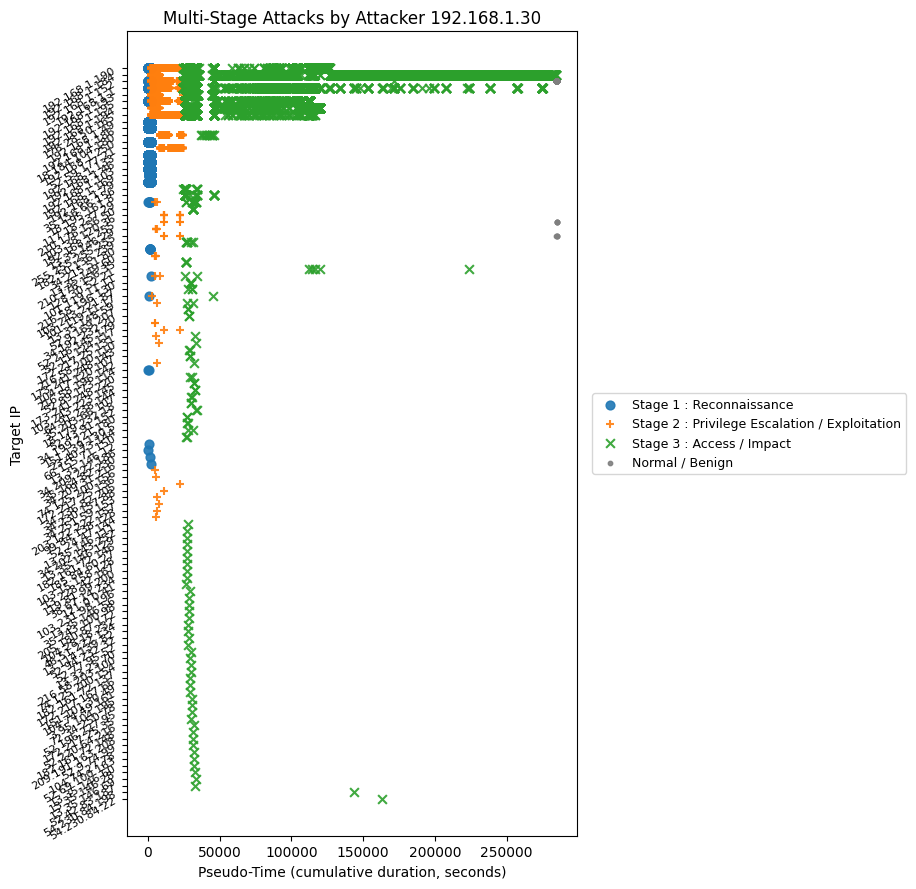

[saved] multistage_ckc_staged.png


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_ckc_staged_pseudotime(
    df4,
    ATTACKER_IP="192.168.1.30",
    DURATION_COL="duration",
    SRC_COL="src_ip",
    DST_COL="dst_ip",
    TYPE_COL="type",
    OUT_PNG="multistage_ckc_staged.png",
    FIGSIZE=(12,9),
    ORDER_BY_COL=None,        # kalau kamu punya kolom urutan asli, isi di sini (mis. "flow_start")
    FORCE_STAGE_ORDER=True    # True = pastikan Stage1 di kiri, lalu Stage2, Stage3
):
    df = df4.copy()

    # Filter attacker dan pastikan duration numerik
    df = df[df[SRC_COL].astype(str) == str(ATTACKER_IP)].copy()
    if df.empty:
        raise ValueError(f"Tidak ada data untuk attacker {ATTACKER_IP}")
    df[DURATION_COL] = pd.to_numeric(df[DURATION_COL], errors="coerce").fillna(0.0)

    # Mapping type -> stage (sesuai daftar kamu)
    def map_stage_from_type(s):
        s = str(s).lower()
        if "normal" in s: return "Normal / Benign"
        if any(k in s for k in ["scann","scan","recon","nmap","probe","crawler","httrack"]):
            return "Stage 1 : Reconnaissance"
        if any(k in s for k in ["injection","xss","mitm","sql","password","login","auth","brute","slowloris","exploit"]):
            return "Stage 2 : Privilege Escalation / Exploitation"
        if any(k in s for k in ["backdoor","ransom","ransomware","ddos","dos","bot","c2","exfil","impact"]):
            return "Stage 3 : Access / Impact"
        return "Unknown/Other"

    df["_stage"] = df[TYPE_COL].astype(str).apply(map_stage_from_type)

    # === KUNCI PERBAIKAN ===
    # Jika tidak ada ORDER_BY_COL (timestamp asli), urutkan berdasarkan urutan stage,
    # supaya Stage 1 selalu muncul di kiri, dilanjut Stage 2, lalu Stage 3.
    stage_rank = {
        "Stage 1 : Reconnaissance": 1,
        "Stage 2 : Privilege Escalation / Exploitation": 2,
        "Stage 3 : Access / Impact": 3,
        "Normal / Benign": 4,
        "Unknown/Other": 5
    }

    if ORDER_BY_COL and ORDER_BY_COL in df.columns:
        df = df.sort_values(by=ORDER_BY_COL).reset_index(drop=True)
        ordering_note = f"ordered by '{ORDER_BY_COL}'"
    elif FORCE_STAGE_ORDER:
        df["_stage_rank"] = df["_stage"].map(stage_rank).fillna(99)
        # stabilkan urutan dalam stage dengan index asli supaya pola aslinya masih kebaca
        df = df.sort_values(by=["_stage_rank"]).reset_index(drop=True)
        ordering_note = "forced by CKC stage order (S1→S2→S3)"
    else:
        df = df.sort_index().reset_index(drop=True)
        ordering_note = "by original row order"

    # Hitung pseudo-time SETELAH pengurutan
    med = float(np.nanmedian(df[DURATION_COL]))
    scale = 1.0 if med <= 1000 else 1/1000.0  # ms → s jika perlu
    df["_pseudo_time"] = (df[DURATION_COL] * scale).cumsum().astype(float)

    # Diagnostik singkat (cek urutan sudah sesuai ekspektasi)
    diag = df.groupby("_stage")["_pseudo_time"].agg(["count","min","median","max"]).sort_values("median")
    print(f"[ordering] {ordering_note}\n\nPseudo-time per stage:\n{diag}\n")

    # Sumbu-Y: target IP
    df["_dst_str"] = df[DST_COL].astype(str)
    dst_order = df["_dst_str"].value_counts().index.tolist()[::-1]
    df["_dst_cat"] = pd.Categorical(df["_dst_str"], categories=dst_order, ordered=True)

    # Style per stage
    colors = {
        "Stage 1 : Reconnaissance":"tab:blue",
        "Stage 2 : Privilege Escalation / Exploitation":"tab:orange",
        "Stage 3 : Access / Impact":"tab:green",
        "Normal / Benign":"tab:gray",
        "Unknown/Other":"tab:red"
    }
    markers = {
        "Stage 1 : Reconnaissance":"o",
        "Stage 2 : Privilege Escalation / Exploitation":"+",
        "Stage 3 : Access / Impact":"x",
        "Normal / Benign":".",
        "Unknown/Other":"D"
    }

    # Plot
    plt.figure(figsize=FIGSIZE)
    ax = plt.gca()
    for stg in ["Stage 1 : Reconnaissance",
                "Stage 2 : Privilege Escalation / Exploitation",
                "Stage 3 : Access / Impact",
                "Normal / Benign",
                "Unknown/Other"]:
        sub = df[df["_stage"] == stg]
        if sub.empty: continue
        ax.scatter(sub["_pseudo_time"], sub["_dst_cat"].cat.codes,
                   s=40, alpha=0.9,
                   color=colors[stg], marker=markers[stg], label=stg)

    ax.set_yticks(range(len(dst_order)))
    ax.set_yticklabels(dst_order, fontsize=8, rotation=30, ha="right")
    ax.set_xlabel("Pseudo-Time (cumulative duration, seconds)")
    ax.set_ylabel("Target IP")
    ax.set_title(f"Multi-Stage Attacks by Attacker {ATTACKER_IP}")
    ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=9)
    plt.tight_layout(rect=[0,0,0.78,1])
    plt.savefig(OUT_PNG, dpi=200, bbox_inches='tight')
    plt.show()
    print(f"[saved] {OUT_PNG}")

    return df[["_pseudo_time", SRC_COL, DST_COL, TYPE_COL, "_stage"]]

# ==== contoh pakai ====
cleaned = plot_ckc_staged_pseudotime(
    df4,
    ATTACKER_IP="192.168.1.30",
    DURATION_COL="duration",
    SRC_COL="src_ip",
    DST_COL="dst_ip",
    TYPE_COL="type",
    ORDER_BY_COL=None,          # kalau ada kolom waktu asli, ganti None -> "nama_kolom"
    FORCE_STAGE_ORDER=True      # pastikan S1 di kiri, lalu S2, lalu S3
)
